In [1]:
import pandas as pd
from IPython.display import display
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load CSV and split features and labels

df = pd.read_csv('null-corrected.csv', index_col=0)
display(df.head())
X = df.iloc[:, :-1]
Y = df.iloc[:, -1:]
display(X.head())
display(Y.head())

# Preprocess features and targets: normalize to [-1, 1]
scaler_X = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler_X.fit_transform(X)

scaler_Y = MinMaxScaler(feature_range=(-1, 1))
Y_scaled = scaler_Y.fit_transform(Y)
# print(Y_scaled)

# Convert targets to tensor (as float for regression)
Y_tensor = torch.tensor(Y_scaled, dtype=torch.float32).squeeze()

# Set device to CUDA if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# LOOCV setup
# folder = LeaveOneOut()
folder = KFold(n_splits=10)
print(len(X_scaled))
folds = list(folder.split(X_scaled))
input_dim = X_scaled.shape[1]
hidden_units = 256

mse_total = 0.0
correct_count = 0  # for accuracy
count = 0


#Stats
loss_history = []

# Outer loop for LOOCV folds
for fold_idx, (train_index, test_index) in enumerate(tqdm(folds, desc="LOOCV Folds"), start=1):
    # if fold_idx > 25: break

    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    Y_train, Y_test = Y_tensor[train_index], Y_tensor[test_index]
    
    # Convert training data to torch tensors (keep on CPU)
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    Y_train_tensor = Y_train.clone().detach()
    
    # Convert test data and move to device
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    Y_test_tensor = Y_test.clone().detach().to(device)
    
    # Create DataLoader for training data with pin_memory enabled for CUDA
    train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                              pin_memory=True if device.type == 'cuda' else False)
    
    # Define model and move it to the device
    model = torch.nn.Sequential(
        torch.nn.Linear(input_dim, hidden_units),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden_units, 1)
    ).to(device)
    
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    fold_loss_history = []
    epochs = 100
    # Inner loop for epochs
    for epoch in tqdm(range(epochs), desc=f"Fold {fold_idx} Epochs", leave=False):
        epoch_loss = 0.0
        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels.unsqueeze(1))
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * inputs.size(0)
        avg_loss = epoch_loss / len(train_loader.dataset)
        fold_loss_history.append(avg_loss)
        # Uncomment to print loss per epoch:
        # tqdm.write(f"Fold {fold_idx} Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")
    loss_history.append(fold_loss_history)
    
    with torch.no_grad():
        output = model(X_test_tensor)
        loss = criterion(output, Y_test_tensor.unsqueeze(1))
        mse_total += loss.item()

        # Vectorized accuracy calculation
        preds = output.squeeze()
        preds_rounded = torch.round(preds * 10) / 10  # round to one decimal
        diff = torch.abs(preds_rounded - Y_test_tensor)
        correct_count += (diff < 0.49).sum().item()
        count += len(Y_test_tensor)


print(f'\nLOOCV Mean Squared Error: {mse_total/count:.4f}')
accuracy = correct_count / count * 100
print(f'LOOCV Accuracy: {accuracy:.2f}%')


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


Using device: cpu
303


LOOCV Folds:   3%|▎         | 9/303 [00:10<04:40,  1.05it/s]

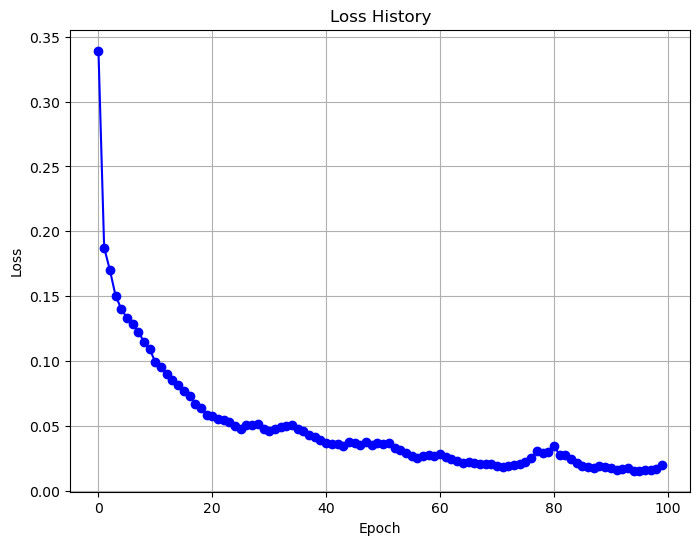

In [3]:
# loss_history = np.array(loss_history)

columns = list(zip(*loss_history))
average_history = [sum(col) / len(col) for col in columns]

plt.figure(figsize=(8, 6))
plt.plot(average_history, marker='o', linestyle='-', color='blue')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

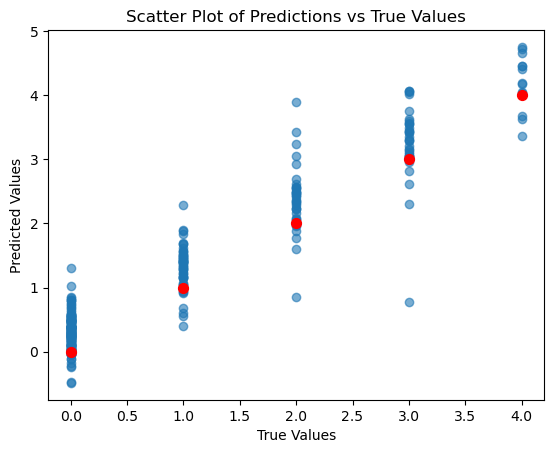

In [4]:
with torch.no_grad():
    x_plot_data = torch.tensor(X_scaled, dtype=torch.float32)
    y_plot_data = torch.tensor(Y_scaled, dtype=torch.float32)
    model.to("cpu")
    output = model(x_plot_data)
    
    y_plot_data = 2 * (y_plot_data + 1)  # Scale back to 0-5
    output = 2 * (output + 1)  # Scale back to 0-5
    plt.scatter(y_plot_data, output, alpha=0.6)
    
    # Add red dots at the coordinates (0,0), (1,1), (2,2), (3,3), (4,4)
    reference_x = [0, 1, 2, 3, 4]
    reference_y = [0, 1, 2, 3, 4]
    plt.scatter(reference_x, reference_y, color='red', s=50)
    
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title('Scatter Plot of Predictions vs True Values')
    plt.show()


In [5]:
baseline_correct = 0
baseline_total = 0
y_np = np.array(Y)
y_mean = y_np.mean()
for i in y_np:
    if abs(i - y_mean) < 0.5:
        baseline_correct =+ 1
    baseline_total += 1

baseline_accuracy = baseline_correct / baseline_total * 100
print(f"y mean: {y_mean}")
print(f"Baseline accuracy: {baseline_accuracy}")
print(f"Regression accuracy: {accuracy}")

y mean: 0.9372937293729373
Baseline accuracy: 0.33003300330033003
Regression accuracy: 61.71617161716172
